# Collapse Analysis: Pretrained vs Random Initialized Model

This notebook compares collapse metrics between:
1. **Pretrained AstroDINO model** - trained with self-supervised learning
2. **Random Initialized ViT** - same architecture, but no pretraining

## Collapse Indicators:
1. **Pairwise Cosine Similarity**: Should have wide distribution, not peaked at 1.0
2. **Per-dimension Variance**: Many dimensions with variance ≈ 0 indicates collapse
3. **Effective Dimensionality**: Features compressed to low-dimensional subspace
4. **Nearest Neighbor Distance Distribution**: Should have variation, not constant

In [1]:
import os
import sys
import numpy as np
import torch
import h5py
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from omegaconf import OmegaConf
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.metrics.pairwise import cosine_similarity

# Add project root to path
PROJECT_ROOT = "/u/yacheng/projects/ssl_outthere"
sys.path.insert(0, PROJECT_ROOT)

from dinov2.eval.setup import build_model_for_eval
from dinov2.models import build_model_from_cfg
from encoder_image.astrodino.train.data.augmentations import ToRGB

/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")


In [2]:
# Configuration
# You can switch between f115w and f150w by changing MODEL_NAME
MODEL_NAME = 'f150w'  # Options: 'f115w' or 'f150w'

MODELS = {
    'f115w': {
        'config': '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f115w_vitl/config.yaml',
        'weights': '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f115w_vitl/eval/training_79999/teacher_checkpoint.pth',
        'data_root': '/u/yacheng/projects/ssl_outthere/images/jwst/f115w'
    },
    'f150w': {
        'config': '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitl/config.yaml',
        'weights': '/u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitl/eval/training_79999/teacher_checkpoint.pth',
        'data_root': '/u/yacheng/projects/ssl_outthere/images/jwst/f150w'
    }
}

MODEL_CONFIG = MODELS[MODEL_NAME]['config']
MODEL_WEIGHTS = MODELS[MODEL_NAME]['weights']
DATA_ROOT = MODELS[MODEL_NAME]['data_root']

BATCH_SIZE = 64
MAX_SAMPLES = 5000  # Number of samples to use for collapse analysis
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'Analyzing model: {MODEL_NAME}')

Using device: cuda:0
Analyzing model: f150w


## 1. Dataset Class

In [3]:
class SimpleJWSTDataset(Dataset):
    """Simple dataset for loading JWST images without label filtering."""
    
    def __init__(self, root: str, crop_size: int = 90, max_samples: int = 5000, seed: int = 42):
        self.crop_size = crop_size
        self.to_rgb = ToRGB()
        self.center_crop = transforms.CenterCrop(crop_size)
        self.rng = np.random.default_rng(seed=seed)
        
        # Load all h5 files
        self._files = []
        self._file_names = []
        h5_files = sorted(f for f in os.listdir(root) if f.endswith('.h5'))
        
        for fname in h5_files:
            fpath = os.path.join(root, fname)
            try:
                f = h5py.File(fpath, 'r')
                if 'image' in f.keys():
                    self._files.append(f)
                    self._file_names.append(fname)
                else:
                    f.close()
            except Exception as e:
                print(f'Error loading {fname}: {e}')
        
        print(f'Loaded {len(self._files)} files')
        
        # Build index of all samples
        self._indices = []  # (file_idx, local_idx)
        for file_idx, f in enumerate(self._files):
            n_samples = f['image'].shape[0]
            for local_idx in range(n_samples):
                self._indices.append((file_idx, local_idx))
        
        print(f'Total samples: {len(self._indices)}')
        
        # Random subsample
        if max_samples > 0 and max_samples < len(self._indices):
            indices = self.rng.choice(len(self._indices), size=max_samples, replace=False)
            self._indices = [self._indices[i] for i in indices]
            print(f'Subsampled to {len(self._indices)} samples')
    
    def __len__(self):
        return len(self._indices)
    
    def __getitem__(self, index):
        file_idx, local_idx = self._indices[index]
        img = self._files[file_idx]['image'][local_idx].astype('float32')
        
        # Convert to 3 channel
        img = np.repeat(img[np.newaxis, :, :], 3, axis=0)
        tensor = torch.from_numpy(img)
        tensor = self.center_crop(tensor)
        tensor = torch.from_numpy(self.to_rgb(tensor.numpy()))
        
        return tensor
    
    def close(self):
        for f in self._files:
            try:
                f.close()
            except:
                pass

## 2. Helper Functions for Collapse Analysis

In [4]:
def compute_embeddings(model, dataset, device, batch_size=64):
    """Compute embeddings for all samples in dataset."""
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    all_embeddings = []
    model.eval()
    
    with torch.no_grad():
        for batch_imgs in tqdm(dataloader, desc='Computing embeddings'):
            batch_imgs = batch_imgs.to(device)
            emb = model(batch_imgs)
            if isinstance(emb, tuple):
                emb = emb[0]
            if emb.dim() > 2:
                emb = emb.view(emb.size(0), -1)
            all_embeddings.append(emb.cpu().numpy())
    
    return np.concatenate(all_embeddings, axis=0)


def l2_normalize(embeddings):
    """L2 normalize embeddings along the feature dimension."""
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    return embeddings / (norms + 1e-8)


def compute_nn_gap(embeddings, k_neighbors=10, n_sample=1000):
    """Compute NN gap ratio for given embeddings."""
    from sklearn.neighbors import NearestNeighbors
    
    n_samples = embeddings.shape[0]
    n_sample = min(n_sample, n_samples)
    idx = np.random.choice(n_samples, n_sample, replace=False)
    emb_sample = embeddings[idx]
    
    nn = NearestNeighbors(n_neighbors=k_neighbors+1, metric='euclidean')
    nn.fit(emb_sample)
    distances, _ = nn.kneighbors(emb_sample)
    
    d1 = distances[:, 1]
    dk = distances[:, k_neighbors]
    nn_gap_ratio = (dk - d1) / (d1 + 1e-8)
    
    return d1, dk, nn_gap_ratio

In [5]:
def analyze_collapse(embeddings, name='Model', k_neighbors=10, normalize=True):
    """Analyze embeddings for signs of collapse with comprehensive metrics.
    
    Args:
        embeddings: Input embeddings of shape (n_samples, n_dims)
        name: Name for display
        k_neighbors: Number of neighbors for NN analysis
        normalize: If True, L2 normalize embeddings before analysis (recommended)
    """
    from sklearn.neighbors import NearestNeighbors
    
    n_samples, n_dims = embeddings.shape
    print(f'\n{"="*70}')
    print(f'Collapse Analysis for {name}')
    print(f'Embeddings shape: {embeddings.shape}')
    print(f'{"="*70}')
    
    # Check original embedding norms
    original_norms = np.linalg.norm(embeddings, axis=1)
    was_normalized = np.allclose(original_norms, 1.0, atol=0.1)
    print(f'Original L2 normalized: {was_normalized} (mean norm: {original_norms.mean():.3f})')
    
    # L2 normalize if requested
    if normalize and not was_normalized:
        print(f'Applying L2 normalization for analysis...')
        embeddings = l2_normalize(embeddings)
    elif normalize and was_normalized:
        print(f'Embeddings already L2 normalized.')
    else:
        print(f'Skipping L2 normalization (normalize=False)')
    
    # Sample for efficiency
    n_sample = min(1000, n_samples)
    idx = np.random.choice(n_samples, n_sample, replace=False)
    emb_sample = embeddings[idx]
    
    # ========== 1. Pairwise Cosine Similarity ==========
    print('\n[1] Pairwise Cosine Similarity')
    cos_sim = cosine_similarity(emb_sample)
    triu_idx = np.triu_indices(n_sample, k=1)
    cos_sim_vals = cos_sim[triu_idx]
    
    cos_mean = cos_sim_vals.mean()
    cos_std = cos_sim_vals.std()
    frac_09 = (cos_sim_vals > 0.9).mean()
    frac_095 = (cos_sim_vals > 0.95).mean()
    
    print(f'  Mean: {cos_mean:.4f}')
    print(f'  Std:  {cos_std:.4f}')
    print(f'  Min:  {cos_sim_vals.min():.4f}, Max: {cos_sim_vals.max():.4f}')
    print(f'  Fraction > 0.9:  {frac_09*100:.2f}%')
    print(f'  Fraction > 0.95: {frac_095*100:.2f}%')
    
    # ========== 2. Per-dimension Variance ==========
    print('\n[2] Per-dimension Variance')
    emb_centered = embeddings - embeddings.mean(axis=0)
    dim_variance = np.var(emb_centered, axis=0)
    
    # For L2 normalized embeddings, expected variance per dim ~ 1/n_dims
    expected_var = 1.0 / n_dims if normalize else None
    dead_threshold = expected_var * 0.01 if normalize else 1e-5  # 1% of expected
    low_threshold = expected_var * 0.1 if normalize else 1e-3   # 10% of expected
    
    dead_dims = (dim_variance < dead_threshold).sum()
    low_dims = (dim_variance < low_threshold).sum()
    
    print(f'  Mean variance: {dim_variance.mean():.6f}')
    print(f'  Std of variance: {dim_variance.std():.6f}')
    if normalize:
        print(f'  Expected variance (isotropic): {expected_var:.6f}')
    print(f'  Dead dims (var < {dead_threshold:.2e}): {dead_dims} / {n_dims}')
    print(f'  Low dims (var < {low_threshold:.2e}): {low_dims} / {n_dims}')
    
    # ========== 3. Effective Dimensionality ==========
    print('\n[3] Effective Dimensionality')
    cov_matrix = np.cov(embeddings.T)
    eigenvalues = np.linalg.eigvalsh(cov_matrix)
    eigenvalues = np.sort(eigenvalues)[::-1]
    eigenvalues = np.maximum(eigenvalues, 1e-12)  # Numerical stability
    
    total_var = eigenvalues.sum()
    normalized_eig = eigenvalues / total_var
    
    # Method 1: Participation Ratio (PR)
    participation_ratio = 1.0 / np.sum(normalized_eig ** 2)
    
    # Method 2: Effective Rank via Entropy (ER)
    entropy = -np.sum(normalized_eig * np.log(normalized_eig + 1e-12))
    effective_rank = np.exp(entropy)
    
    # Variance explained
    cumsum = np.cumsum(eigenvalues) / total_var
    dims_90 = np.searchsorted(cumsum, 0.90) + 1
    dims_95 = np.searchsorted(cumsum, 0.95) + 1
    dims_99 = np.searchsorted(cumsum, 0.99) + 1
    
    print(f'  Participation Ratio (PR): {participation_ratio:.2f} / {n_dims}')
    print(f'  Effective Rank (Entropy): {effective_rank:.2f} / {n_dims}')
    print(f'  Dims for 90% variance: {dims_90}')
    print(f'  Dims for 95% variance: {dims_95}')
    print(f'  Dims for 99% variance: {dims_99}')
    print(f'  Top eigenvalue ratio: {eigenvalues[0]/total_var*100:.2f}%')
    
    # ========== 4. Nearest Neighbor Analysis ==========
    print(f'\n[4] Nearest Neighbor Analysis (k={k_neighbors})')
    d1, dk, nn_gap_ratio = compute_nn_gap(embeddings, k_neighbors, n_sample)
    
    print(f'  d_1 (1st NN): mean={d1.mean():.4f}, std={d1.std():.4f}')
    print(f'  d_{k_neighbors} ({k_neighbors}th NN): mean={dk.mean():.4f}, std={dk.std():.4f}')
    print(f'  NN Gap Ratio (d_k-d_1)/d_1:')
    print(f'    Mean: {nn_gap_ratio.mean():.4f}')
    print(f'    Std:  {nn_gap_ratio.std():.4f}')
    print(f'  Distance Variance Var(d_1): {d1.var():.4f}')
    
    return {
        'cos_sim': cos_sim_vals,
        'cos_mean': cos_mean,
        'cos_std': cos_std,
        'dim_variance': dim_variance,
        'eigenvalues': eigenvalues,
        'cumsum_var': cumsum,
        'participation_ratio': participation_ratio,
        'effective_rank': effective_rank,
        'd1': d1,
        'dk': dk,
        'nn_gap_ratio': nn_gap_ratio,
        'k_neighbors': k_neighbors,
        'dims_90': dims_90,
        'dims_95': dims_95,
        'dims_99': dims_99,
        'was_normalized': was_normalized,
        'normalize_applied': normalize,
    }

In [6]:
def plot_comparison(results_pretrained, results_random, model_name='Model'):
    """Plot side-by-side comparison of pretrained vs random initialized model.
    
    Layout (2 rows x 3 cols):
    - Row 1: Cosine Similarity, NN Distance, NN Gap Ratio
    - Row 2: Per-dimension Variance, Eigenvalue Spectrum, Cumulative Variance
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'Collapse Analysis Comparison: Pretrained vs Random ({model_name})', 
                 fontsize=14, fontweight='bold')
    
    # ========== Row 0: Similarity & Distance Metrics ==========
    
    # Row 0, Col 0: Cosine Similarity Histogram
    ax = axes[0, 0]
    ax.hist(results_pretrained['cos_sim'], bins=50, alpha=0.7, color='blue', 
            edgecolor='black', label=f'Pretrained (μ={results_pretrained["cos_mean"]:.3f})', density=True)
    ax.hist(results_random['cos_sim'], bins=50, alpha=0.7, color='orange', 
            edgecolor='black', label=f'Random (μ={results_random["cos_mean"]:.3f})', density=True)
    ax.axvline(x=0.9, color='r', linestyle='--', linewidth=2, label='0.9 (danger)')
    ax.set_xlabel('Cosine Similarity', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title('Pairwise Cosine Similarity', fontsize=12)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    # Row 0, Col 1: NN Distance Comparison
    ax = axes[0, 1]
    ax.hist(results_pretrained['d1'], bins=40, alpha=0.7, 
            label=f'Pretrained (μ={results_pretrained["d1"].mean():.3f})', 
            color='blue', edgecolor='black', density=True)
    ax.hist(results_random['d1'], bins=40, alpha=0.7, 
            label=f'Random (μ={results_random["d1"].mean():.3f})', 
            color='orange', edgecolor='black', density=True)
    ax.set_xlabel('L2 Distance to 1st NN', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title('1st NN Distance Distribution', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Row 0, Col 2: NN Gap Ratio Comparison
    ax = axes[0, 2]
    k = results_pretrained['k_neighbors']
    ax.hist(results_pretrained['nn_gap_ratio'], bins=40, alpha=0.7, color='blue', 
            edgecolor='black', label=f'Pretrained (μ={results_pretrained["nn_gap_ratio"].mean():.3f})', density=True)
    ax.hist(results_random['nn_gap_ratio'], bins=40, alpha=0.7, color='orange', 
            edgecolor='black', label=f'Random (μ={results_random["nn_gap_ratio"].mean():.3f})', density=True)
    ax.set_xlabel(f'Gap Ratio: (d_{k} - d_1) / d_1', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'NN Gap Ratio (k={k})', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # ========== Row 1: Variance & Dimensionality Metrics ==========
    
    # Row 1, Col 0: Per-dimension Variance (sorted)
    ax = axes[1, 0]
    sorted_var_pretrained = np.sort(results_pretrained['dim_variance'])[::-1]
    sorted_var_random = np.sort(results_random['dim_variance'])[::-1]
    ax.semilogy(sorted_var_pretrained, color='blue', linewidth=1.5, 
                label=f'Pretrained (μ={results_pretrained["dim_variance"].mean():.2e})')
    ax.semilogy(sorted_var_random, color='orange', linewidth=1.5, 
                label=f'Random (μ={results_random["dim_variance"].mean():.2e})')
    ax.axhline(y=1e-5, color='r', linestyle='--', linewidth=2, label='1e-5 (dead)')
    ax.set_xlabel('Dimension (sorted by variance)', fontsize=11)
    ax.set_ylabel('Variance (log scale)', fontsize=11)
    ax.set_title('Per-dimension Variance', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Row 1, Col 1: Eigenvalue Spectrum
    ax = axes[1, 1]
    n_show = min(200, len(results_pretrained['eigenvalues']))
    ax.semilogy(results_pretrained['eigenvalues'][:n_show], color='blue', linewidth=2, label='Pretrained')
    ax.semilogy(results_random['eigenvalues'][:n_show], color='orange', linewidth=2, label='Random')
    ax.set_xlabel('Eigenvalue Index', fontsize=11)
    ax.set_ylabel('Eigenvalue (log scale)', fontsize=11)
    ax.set_title('Covariance Eigenvalue Spectrum', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Row 1, Col 2: Cumulative Variance Explained
    ax = axes[1, 2]
    n_show = min(300, len(results_pretrained['cumsum_var']))
    ax.plot(results_pretrained['cumsum_var'][:n_show], linewidth=2, color='blue', label='Pretrained')
    ax.plot(results_random['cumsum_var'][:n_show], linewidth=2, color='orange', label='Random')
    ax.axhline(y=0.90, color='r', linestyle='--', alpha=0.7, label='90%')
    ax.axhline(y=0.95, color='green', linestyle='--', alpha=0.7, label='95%')
    ax.axvline(x=results_pretrained['effective_rank'], color='blue', linestyle=':', linewidth=2, 
               label=f'Pretrained ER: {results_pretrained["effective_rank"]:.0f}')
    ax.axvline(x=results_random['effective_rank'], color='orange', linestyle=':', linewidth=2,
               label=f'Random ER: {results_random["effective_rank"]:.0f}')
    ax.set_xlabel('Number of Principal Components', fontsize=11)
    ax.set_ylabel('Cumulative Variance Explained', fontsize=11)
    ax.set_title('Effective Dimensionality', fontsize=12)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, n_show)
    
    plt.tight_layout()
    plt.show()
    
    return fig

## 3. Load Pretrained Model

In [7]:
# Load configuration
cfg = OmegaConf.load(MODEL_CONFIG)
print(f'Config loaded: {MODEL_CONFIG}')
print(f'Model architecture: {cfg.student.arch}')
print(f'Crop size: {cfg.crops.global_crops_size}')

Config loaded: /u/yacheng/projects/ssl_outthere/encoder_image/astrodino/model/astrodino_f150w_vitl/config.yaml
Model architecture: vit_large
Crop size: 90


In [8]:
# Load pretrained model
print('Loading pretrained model...')
model_pretrained = build_model_for_eval(cfg, pretrained_weights=MODEL_WEIGHTS)
model_pretrained = model_pretrained.to(DEVICE)
model_pretrained.eval()
print(f'Pretrained model loaded successfully')

Loading pretrained model...
Pretrained model loaded successfully


## 4. Build Random Initialized Model

Using the same architecture as the pretrained model, but with randomly initialized weights (no pretraining).

In [9]:
# Build randomly initialized model with same architecture (no pretrained weights)
print('Building randomly initialized ViT model (same architecture, no pretraining)...')

# This creates a model with the same config but random weights
model_random, embed_dim_random = build_model_from_cfg(cfg, only_teacher=True)
model_random = model_random.to(DEVICE)
model_random.eval()

print(f'Random ViT model created, embed_dim={embed_dim_random}')
print(f'Architecture: {cfg.student.arch}')

Building randomly initialized ViT model (same architecture, no pretraining)...
Random ViT model created, embed_dim=1024
Architecture: vit_large


## 5. Create Dataset

In [10]:
# Create dataset
crop_size = cfg.crops.global_crops_size
dataset = SimpleJWSTDataset(
    DATA_ROOT,
    crop_size=crop_size,
    max_samples=MAX_SAMPLES
)
print(f'Dataset size: {len(dataset)}')

Loaded 20 files
Total samples: 641150
Subsampled to 5000 samples
Dataset size: 5000


## 6. Compute Embeddings

In [11]:
# Compute embeddings for pretrained model
print('Computing embeddings with pretrained model...')
embeddings_pretrained = compute_embeddings(model_pretrained, dataset, DEVICE, BATCH_SIZE)
print(f'Pretrained embeddings shape: {embeddings_pretrained.shape}')

Computing embeddings with pretrained model...


Computing embeddings: 100%|██████████| 79/79 [02:05<00:00,  1.59s/it]

Pretrained embeddings shape: (5000, 1024)


In [12]:
# Compute embeddings for random initialized model
print('Computing embeddings with random initialized model...')
embeddings_random = compute_embeddings(model_random, dataset, DEVICE, BATCH_SIZE)
print(f'Random embeddings shape: {embeddings_random.shape}')

Computing embeddings with random initialized model...


Computing embeddings: 100%|██████████| 79/79 [00:18<00:00,  4.32it/s]

Random embeddings shape: (5000, 1024)


## 7. Collapse Analysis

In [13]:
# Analyze pretrained model
results_pretrained = analyze_collapse(embeddings_pretrained, name=f'Pretrained AstroDINO ({MODEL_NAME})')


Collapse Analysis for Pretrained AstroDINO (f150w)
Embeddings shape: (5000, 1024)
Original L2 normalized: False (mean norm: 32.500)
Applying L2 normalization for analysis...

[1] Pairwise Cosine Similarity
  Mean: 0.0885
  Std:  0.1459
  Min:  -0.3024, Max: 0.9507
  Fraction > 0.9:  0.00%
  Fraction > 0.95: 0.00%

[2] Per-dimension Variance
  Mean variance: 0.000890
  Std of variance: 0.000730
  Expected variance (isotropic): 0.000977
  Dead dims (var < 9.77e-06): 0 / 1024
  Low dims (var < 9.77e-05): 13 / 1024

[3] Effective Dimensionality
  Participation Ratio (PR): 47.46 / 1024
  Effective Rank (Entropy): 103.03 / 1024
  Dims for 90% variance: 120
  Dims for 95% variance: 196
  Dims for 99% variance: 449
  Top eigenvalue ratio: 6.40%

[4] Nearest Neighbor Analysis (k=10)
  d_1 (1st NN): mean=0.8347, std=0.1404
  d_10 (10th NN): mean=1.0038, std=0.0982
  NN Gap Ratio (d_k-d_1)/d_1:
    Mean: 0.2297
    Std:  0.2235
  Distance Variance Var(d_1): 0.0197


In [14]:
# Analyze random initialized model
results_random = analyze_collapse(embeddings_random, name=f'Random Initialized ViT ({MODEL_NAME})')


Collapse Analysis for Random Initialized ViT (f150w)
Embeddings shape: (5000, 1024)
Original L2 normalized: False (mean norm: 31.958)
Applying L2 normalization for analysis...

[1] Pairwise Cosine Similarity
  Mean: 1.0000
  Std:  0.0000
  Min:  1.0000, Max: 1.0000
  Fraction > 0.9:  100.00%
  Fraction > 0.95: 100.00%

[2] Per-dimension Variance
  Mean variance: 0.000000
  Std of variance: 0.000000
  Expected variance (isotropic): 0.000977
  Dead dims (var < 9.77e-06): 1024 / 1024
  Low dims (var < 9.77e-05): 1024 / 1024

[3] Effective Dimensionality
  Participation Ratio (PR): 11.41 / 1024
  Effective Rank (Entropy): 78.83 / 1024
  Dims for 90% variance: 470
  Dims for 95% variance: 747
  Dims for 99% variance: 969
  Top eigenvalue ratio: 27.52%

[4] Nearest Neighbor Analysis (k=10)
  d_1 (1st NN): mean=0.0001, std=0.0000
  d_10 (10th NN): mean=0.0001, std=0.0000
  NN Gap Ratio (d_k-d_1)/d_1:
    Mean: 0.1302
    Std:  0.4629
  Distance Variance Var(d_1): 0.0000


## 8. Comparison Visualization

/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: divide by zero encountered in divide
  return n/db/n.sum(), bin_edges
/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


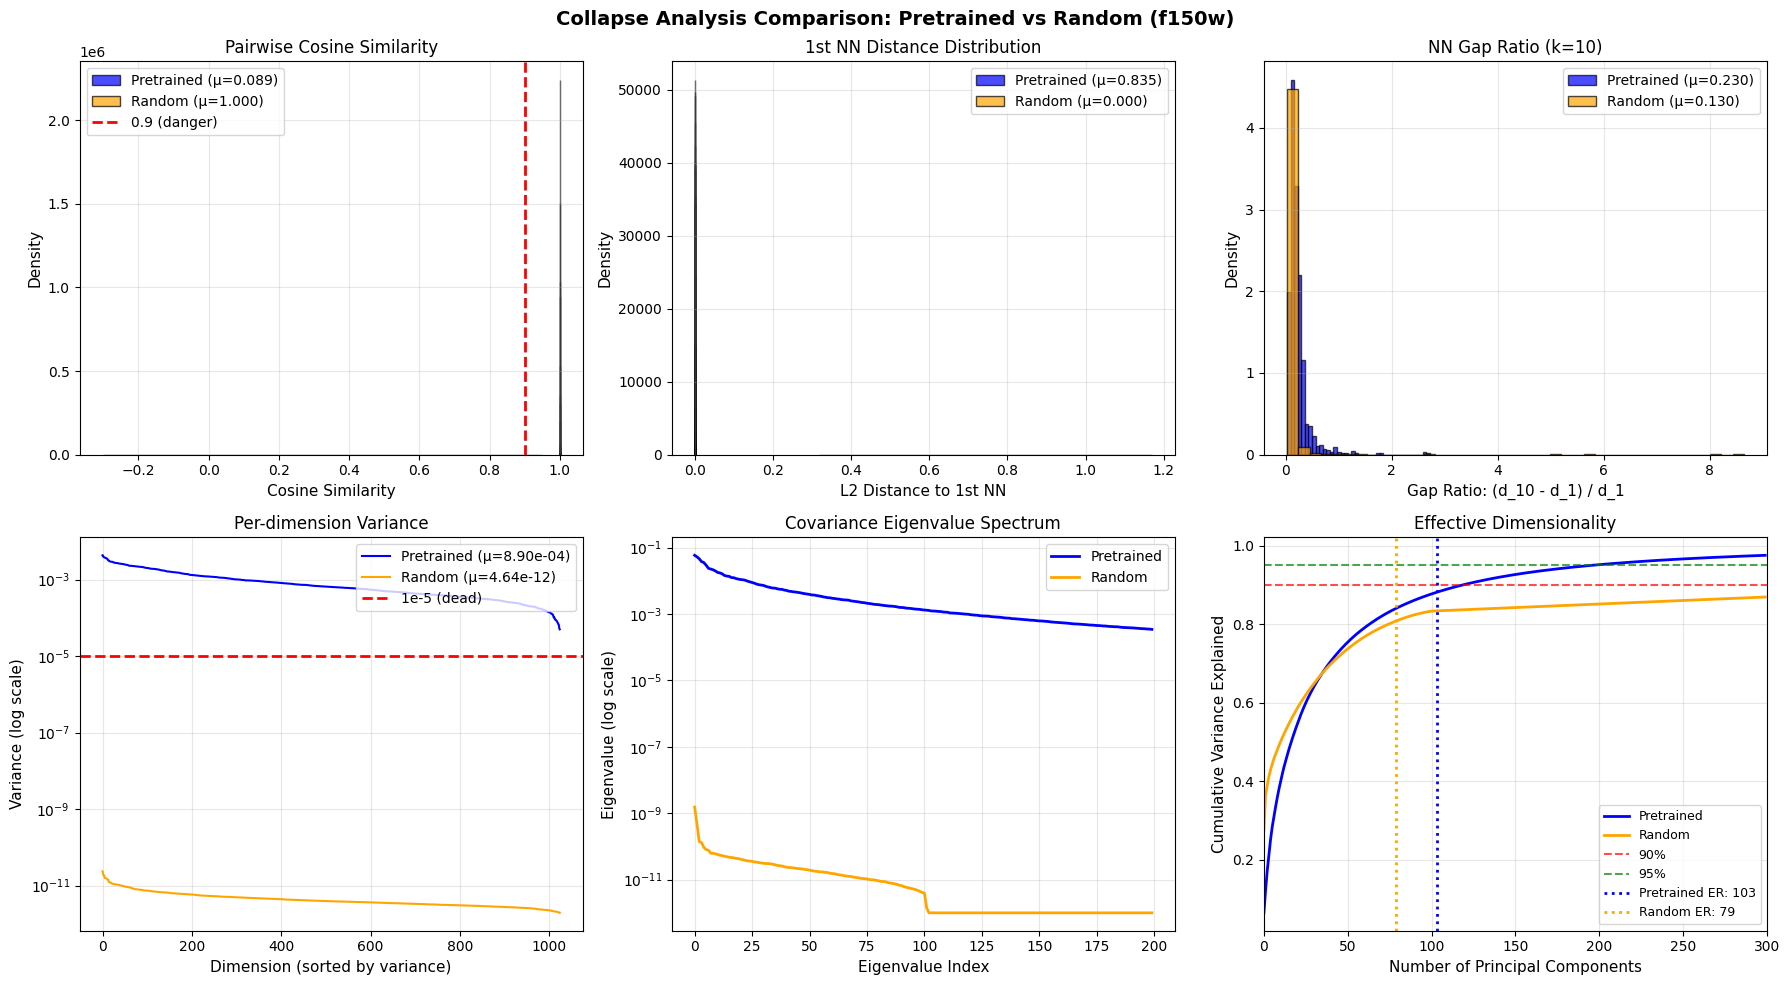

In [15]:
# Plot comparison
fig = plot_comparison(results_pretrained, results_random, model_name=MODEL_NAME)

In [16]:
# Summary comparison table
print('\n' + '='*80)
print(f'COLLAPSE ANALYSIS SUMMARY: {MODEL_NAME}')
print('='*80)

print(f"\n{'Metric':<40} {'Pretrained':>15} {'Random':>15}")
print('-'*80)

print(f"{'Mean Cosine Similarity':<40} {results_pretrained['cos_mean']:>15.4f} {results_random['cos_mean']:>15.4f}")
print(f"{'Std Cosine Similarity':<40} {results_pretrained['cos_std']:>15.4f} {results_random['cos_std']:>15.4f}")
print(f"{'Fraction cos_sim > 0.9':<40} {(results_pretrained['cos_sim'] > 0.9).mean()*100:>14.2f}% {(results_random['cos_sim'] > 0.9).mean()*100:>14.2f}%")
print(f"{'Fraction cos_sim > 0.95':<40} {(results_pretrained['cos_sim'] > 0.95).mean()*100:>14.2f}% {(results_random['cos_sim'] > 0.95).mean()*100:>14.2f}%")
print(f"{'Participation Ratio':<40} {results_pretrained['participation_ratio']:>15.1f} {results_random['participation_ratio']:>15.1f}")
print(f"{'Effective Rank (Entropy)':<40} {results_pretrained['effective_rank']:>15.1f} {results_random['effective_rank']:>15.1f}")
print(f"{'Dims for 90% variance':<40} {results_pretrained['dims_90']:>15} {results_random['dims_90']:>15}")
print(f"{'Dims for 95% variance':<40} {results_pretrained['dims_95']:>15} {results_random['dims_95']:>15}")
print(f"{'Mean NN Distance (d_1)':<40} {results_pretrained['d1'].mean():>15.4f} {results_random['d1'].mean():>15.4f}")
print(f"{'Std NN Distance (d_1)':<40} {results_pretrained['d1'].std():>15.4f} {results_random['d1'].std():>15.4f}")
print(f"{'Mean NN Gap Ratio':<40} {results_pretrained['nn_gap_ratio'].mean():>15.4f} {results_random['nn_gap_ratio'].mean():>15.4f}")
print(f"{'Mean Dim Variance':<40} {results_pretrained['dim_variance'].mean():>15.6f} {results_random['dim_variance'].mean():>15.6f}")

print('\n' + '='*80)


COLLAPSE ANALYSIS SUMMARY: f150w

Metric                                        Pretrained          Random
--------------------------------------------------------------------------------
Mean Cosine Similarity                            0.0885          1.0000
Std Cosine Similarity                             0.1459          0.0000
Fraction cos_sim > 0.9                             0.00%         100.00%
Fraction cos_sim > 0.95                            0.00%         100.00%
Participation Ratio                                 47.5            11.4
Effective Rank (Entropy)                           103.0            78.8
Dims for 90% variance                                120             470
Dims for 95% variance                                196             747
Mean NN Distance (d_1)                            0.8347          0.0001
Std NN Distance (d_1)                             0.1404          0.0000
Mean NN Gap Ratio                                 0.2297          0.1302
Mean Dim

In [17]:
# Diagnosis
print('\n' + '='*80)
print('COLLAPSE DIAGNOSIS')
print('='*80)

for name, results in [('Pretrained', results_pretrained), ('Random', results_random)]:
    cos_mean = results['cos_mean']
    cos_frac_09 = (results['cos_sim'] > 0.9).mean()
    eff_dim = results['participation_ratio']
    nn_gap = results['nn_gap_ratio'].mean()
    
    print(f'\n{name}:')
    
    # Cosine similarity diagnosis
    if cos_mean > 0.9 or cos_frac_09 > 0.5:
        print(f'  ⚠️  HIGH cosine similarity (mean={cos_mean:.3f}, {cos_frac_09*100:.1f}% > 0.9) - POSSIBLE COLLAPSE')
    elif cos_mean > 0.7:
        print(f'  ⚠ Moderate cosine similarity (mean={cos_mean:.3f})')
    else:
        print(f'  ✓ Cosine similarity looks healthy (mean={cos_mean:.3f})')
    
    # Effective dimensionality diagnosis
    if eff_dim < 10:
        print(f'  ⚠️  LOW effective dimensionality ({eff_dim:.1f}) - POSSIBLE COLLAPSE')
    elif eff_dim < 50:
        print(f'  ⚠ Moderate effective dimensionality ({eff_dim:.1f})')
    else:
        print(f'  ✓ Effective dimensionality looks healthy ({eff_dim:.1f})')
    
    # NN gap ratio diagnosis (higher is better - indicates local structure)
    if nn_gap < 0.5:
        print(f'  ⚠️  LOW NN gap ratio ({nn_gap:.3f}) - embeddings may be too uniform')
    else:
        print(f'  ✓ NN gap ratio looks healthy ({nn_gap:.3f})')

# Compare pretrained vs random
print('\n' + '-'*80)
print('PRETRAINED vs RANDOM COMPARISON:')
print('-'*80)

cos_diff = results_pretrained['cos_mean'] - results_random['cos_mean']
eff_dim_diff = results_pretrained['participation_ratio'] - results_random['participation_ratio']
nn_gap_diff = results_pretrained['nn_gap_ratio'].mean() - results_random['nn_gap_ratio'].mean()

print(f'Cosine Similarity Difference: {cos_diff:+.4f}')
if cos_diff > 0.1:
    print('  → Pretrained has HIGHER cosine similarity (may indicate learning, or potential collapse)')
elif cos_diff < -0.1:
    print('  → Pretrained has LOWER cosine similarity (more diverse representations)')
else:
    print('  → Similar cosine similarity')

print(f'\nEffective Dimensionality Difference: {eff_dim_diff:+.1f}')
if eff_dim_diff > 20:
    print('  → Pretrained uses MORE dimensions effectively (better feature utilization)')
elif eff_dim_diff < -20:
    print('  → Pretrained uses FEWER dimensions (may indicate learned compression or collapse)')
else:
    print('  → Similar effective dimensionality')

print(f'\nNN Gap Ratio Difference: {nn_gap_diff:+.4f}')
if nn_gap_diff > 0.1:
    print('  → Pretrained has MORE local structure (semantic clustering)')
elif nn_gap_diff < -0.1:
    print('  → Pretrained has LESS local structure')
else:
    print('  → Similar local structure')

print('\n' + '='*80)


COLLAPSE DIAGNOSIS

Pretrained:
  ✓ Cosine similarity looks healthy (mean=0.089)
  ⚠ Moderate effective dimensionality (47.5)
  ⚠️  LOW NN gap ratio (0.230) - embeddings may be too uniform

Random:
  ⚠️  HIGH cosine similarity (mean=1.000, 100.0% > 0.9) - POSSIBLE COLLAPSE
  ⚠ Moderate effective dimensionality (11.4)
  ⚠️  LOW NN gap ratio (0.130) - embeddings may be too uniform

--------------------------------------------------------------------------------
PRETRAINED vs RANDOM COMPARISON:
--------------------------------------------------------------------------------
Cosine Similarity Difference: -0.9115
  → Pretrained has LOWER cosine similarity (more diverse representations)

Effective Dimensionality Difference: +36.1
  → Pretrained uses MORE dimensions effectively (better feature utilization)

NN Gap Ratio Difference: +0.0995
  → Similar local structure



## 9. Cleanup

In [ ]:
# Clean up resources
dataset.close()
del model_pretrained
del model_random
torch.cuda.empty_cache()
print('Resources released')